# Distinguishing Dataset ICA analysis — standardized BIDS only

Этот notebook читает только standardized Dataset A BIDS (`datasets/bids/distinguishing`) и ничего не берёт из `prepared_cache`. Он предназначен для выбора ICA-правила **до** реализации нового preparation recipe. Все преобразования существуют только в памяти.

In [3]:
from pathlib import Path

import mne
import numpy as np
import pandas as pd
from mne.preprocessing import ICA
from mne_bids import find_matching_paths, read_raw_bids

%matplotlib inline
mne.viz.set_browser_backend('matplotlib')
mne.set_log_level('ERROR')
pd.set_option('display.width', 160)

DATASET = 'distinguishing'
BIDS_ROOT = Path.cwd().resolve().parent / 'datasets' / 'bids' / DATASET
SAMPLE_SUBJECT = '01'
SAMPLE_SESSION = '01'
CHANNELS = ['F3', 'F4', 'F7', 'F8', 'FC5', 'FC6', 'O1', 'O2', 'P7', 'P8', 'T7', 'T8']
PROXY_CHANNELS = ['F3', 'F4', 'F7', 'F8']
L_FREQ, H_FREQ = 1., 40.
ICA_RANDOM_STATE = 42

if not BIDS_ROOT.is_dir():
    raise FileNotFoundError(f'Standardized BIDS root is missing: {BIDS_ROOT}')

## Inventory from standardization

Dataset A ICA unit — `(subject, session, run)`. Этот inventory нужен для заранее фиксированного QC-набора; он не использует labels, prepared epochs или результаты decoder-а.

In [4]:
paths = sorted(
    find_matching_paths(BIDS_ROOT, datatypes='eeg', suffixes='eeg', extensions='.vhdr'),
    key=lambda path: (path.subject, path.session or '', path.run or '', path.task),
)
inventory = pd.DataFrame([
    {'subject': path.subject, 'session': path.session, 'run': path.run, 'task': path.task,
     'recording_unit': (path.subject, path.session, path.run),
     'file': str(path.fpath.relative_to(BIDS_ROOT))}
    for path in paths
])
if inventory.empty:
    raise ValueError(f'No standardized EEG recordings found under {BIDS_ROOT}')
print(f'recordings={len(inventory)}, ICA units={inventory.recording_unit.nunique()}')
inventory.groupby(['subject', 'session', 'run'], dropna=False).size().describe(), inventory.head(12)


recordings=34, ICA units=34


(count    34.0
 mean      1.0
 std       0.0
 min       1.0
 25%       1.0
 50%       1.0
 75%       1.0
 max       1.0
 dtype: float64,
    subject session   run       task  recording_unit                                               file
 0       01      01  None  attention  (01, 01, None)  sub-01/ses-01/eeg/sub-01_ses-01_task-attention...
 1       01      02  None  attention  (01, 02, None)  sub-01/ses-02/eeg/sub-01_ses-02_task-attention...
 2       01      03  None  attention  (01, 03, None)  sub-01/ses-03/eeg/sub-01_ses-03_task-attention...
 3       01      04  None  attention  (01, 04, None)  sub-01/ses-04/eeg/sub-01_ses-04_task-attention...
 4       01      05  None  attention  (01, 05, None)  sub-01/ses-05/eeg/sub-01_ses-05_task-attention...
 5       01      06  None  attention  (01, 06, None)  sub-01/ses-06/eeg/sub-01_ses-06_task-attention...
 6       01      07  None  attention  (01, 07, None)  sub-01/ses-07/eeg/sub-01_ses-07_task-attention...
 7       02      01  None  atte

## In-memory ICA audit for one standardized recording unit

Это намеренно не production preprocessing: здесь нет channel interpolation, amplitude annotation, epoch rejection и записи на диск. Цель — увидеть, что именно выбирает proxy rule на одинаковом standardized input. `no_ica` — baseline с пустым `exclude`; `ica_proxy` — текущая эвристика F3/F4/F7/F8.

n_components=4; proxy-excluded=[]; removed variance=-0.0%
No proxy-selected components to plot.


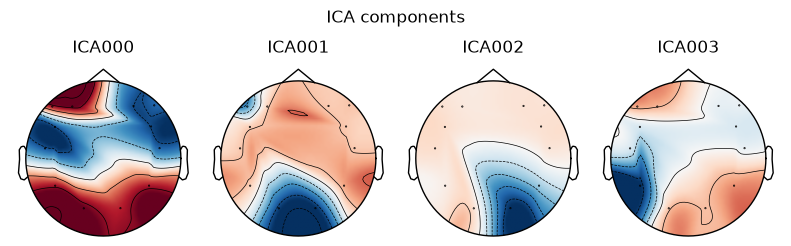

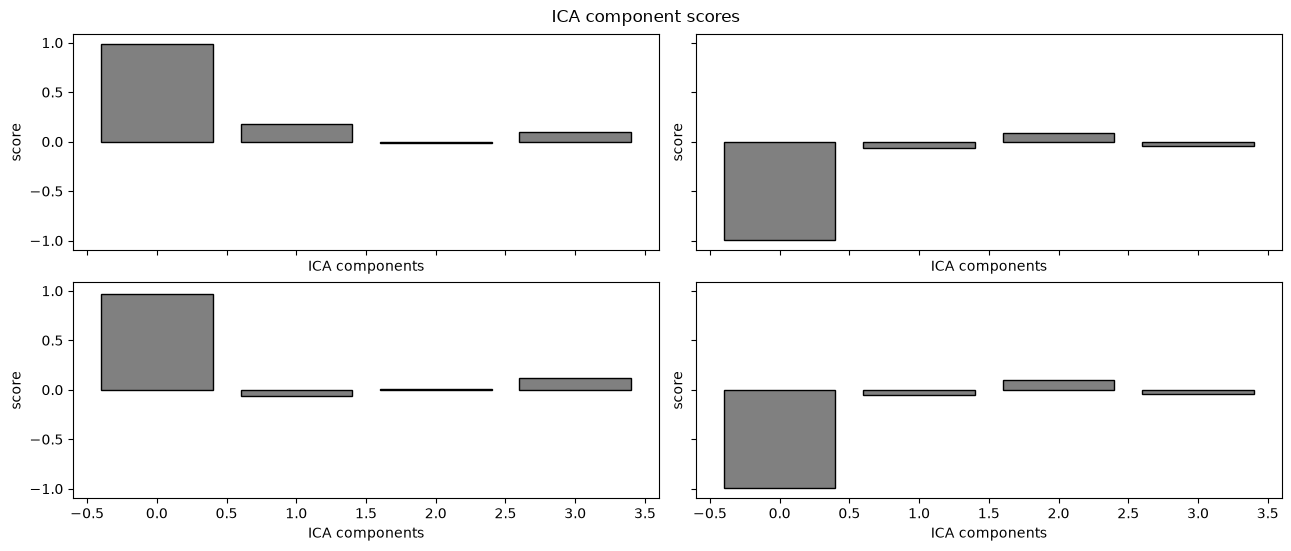

In [5]:
sample_paths = [path for path in paths if path.subject == SAMPLE_SUBJECT and path.session == SAMPLE_SESSION]
if not sample_paths:
    raise ValueError(f'No standardized Dataset A unit for sub-{SAMPLE_SUBJECT}, ses-{SAMPLE_SESSION}')

raws = []
for path in sorted(sample_paths, key=lambda path: path.task):
    raw = read_raw_bids(path, verbose='ERROR').load_data().pick('eeg')
    if set(CHANNELS) - set(raw.ch_names):
        raise ValueError(f'{path.basename} lacks common channels {sorted(set(CHANNELS) - set(raw.ch_names))}')
    notch = [50.] if 50. < raw.info['sfreq'] / 2 else []
    if notch:
        raw.notch_filter(notch, verbose='ERROR')
    raw.filter(L_FREQ, H_FREQ, verbose='ERROR').pick(CHANNELS)
    raw.set_eeg_reference('average', projection=False, verbose='ERROR')
    raws.append(raw)

fit_raw = mne.concatenate_raws([raw.copy() for raw in raws], verbose='ERROR')
ica = ICA(n_components=0.99, method='fastica', random_state=ICA_RANDOM_STATE, max_iter='auto')
ica.fit(fit_raw, reject_by_annotation=True, verbose='ERROR')
proxy_idx, proxy_scores = ica.find_bads_eog(
    fit_raw, ch_name=PROXY_CHANNELS, threshold=2.4, measure='zscore', verbose='ERROR'
)

proxy_clean = fit_raw.copy()
ica_proxy = ica.copy()
ica_proxy.exclude = proxy_idx
ica_proxy.apply(proxy_clean, verbose='ERROR')
variance_before = fit_raw.get_data().var(axis=1).sum()
variance_after = proxy_clean.get_data().var(axis=1).sum()
print(f'n_components={ica.n_components_}; proxy-excluded={proxy_idx}; removed variance={1 - variance_after / variance_before:.1%}')
ica.plot_components(show=False)
ica.plot_scores(proxy_scores, exclude=proxy_idx, show=False)
if proxy_idx:
    ica.plot_properties(fit_raw, picks=proxy_idx, show=False)
else:
    print('No proxy-selected components to plot.')


## Decision before preparation

Не выбирать порог или набор IC по balanced accuracy. Сначала прогнать тот же audit на заранее зафиксированном наборе units и сравнить: число исключённых IC, снятую дисперсию, IC topography/time course и PSD.

`no_ica` остаётся реальным кандидатом. ICLabel — отдельный кандидат, а не fallback: для него нужен отдельный fit (extended Infomax, CAR, 1–100 Hz и установленный `mne-icalabel` runtime). После решения его правило будет внесено в preparation как новый content-addressed recipe.

## Bad-channel QC on standardized raw

Read-only аудит: используются те же filtering и параметры amplitude/LOF, что в текущем preparation, но BIDS и prepared cache не меняются. BAD_peak/BAD_flat — временные spans; канал, обнаруженный amplitude или LOF, — отдельный результат.

In [6]:
QC_PEAK_UV = 150.0
QC_FLAT_UV = 0.0
QC_BAD_PERCENT = 5.0
QC_MIN_DURATION_S = 0.5
QC_LOF_NEIGHBORS = 10
QC_LOF_THRESHOLD = 1.5

def load_qc_raw(path):
    raw = read_raw_bids(path, verbose='ERROR').load_data().pick('eeg')
    missing = sorted(set(CHANNELS) - set(raw.ch_names))
    if missing:
        raise ValueError(f'{path.basename} lacks common channels {missing}')
    if 50. < raw.info['sfreq'] / 2:
        raw.notch_filter([50.], verbose='ERROR')
    raw.filter(L_FREQ, H_FREQ, verbose='ERROR').pick(CHANNELS)
    annotations, amplitude_bads = mne.preprocessing.annotate_amplitude(
        raw, peak={'eeg': QC_PEAK_UV * 1e-6}, flat={'eeg': QC_FLAT_UV * 1e-6},
        bad_percent=QC_BAD_PERCENT, min_duration=QC_MIN_DURATION_S, verbose='ERROR'
    )
    raw.set_annotations(raw.annotations + annotations)
    lof_bads, lof_scores = mne.preprocessing.find_bad_channels_lof(
        raw, n_neighbors=QC_LOF_NEIGHBORS, threshold=QC_LOF_THRESHOLD,
        return_scores=True, verbose='ERROR'
    )
    return raw, annotations, sorted(amplitude_bads), sorted(lof_bads), lof_scores

qc_rows = []
for path in paths:
    raw, annotations, amplitude_bads, lof_bads, lof_scores = load_qc_raw(path)
    auto_bads = sorted(set(amplitude_bads) | set(lof_bads))
    qc_rows.append({
        'file': str(path.fpath.relative_to(BIDS_ROOT)), 'subject': path.subject, 'session': path.session,
        'bad_span_count': len(annotations), 'bad_span_s': float(annotations.duration.sum()),
        'amplitude_bads': amplitude_bads, 'lof_bads': lof_bads, 'auto_bads': auto_bads,
        'max_lof_score': float(np.max(lof_scores)),
    })
qc = pd.DataFrame(qc_rows)
print(f"recordings with >=1 candidate bad channel: {(qc.auto_bads.str.len() > 0).sum()}/{len(qc)}")
print(f"recordings with >1 candidate (would stop current recipe): {(qc.auto_bads.str.len() > 1).sum()}/{len(qc)}")
qc.sort_values(['max_lof_score', 'bad_span_s'], ascending=False).head(20)


recordings with >=1 candidate bad channel: 7/34
recordings with >1 candidate (would stop current recipe): 0/34


,file,subject,session,bad_span_count,bad_span_s,amplitude_bads,lof_bads,auto_bads,max_lof_score
1,sub-01/ses-02/eeg/sub-01_ses-02_task-attention...,01,02,0,0.0,[],[],[],-0.962963
2,sub-01/ses-03/eeg/sub-01_ses-03_task-attention...,01,03,0,0.0,[],[],[],-0.971931
27,sub-04/ses-07/eeg/sub-04_ses-07_task-attention...,04,07,0,0.0,[],[],[],-0.976249
9,sub-02/ses-03/eeg/sub-02_ses-03_task-attention...,02,03,0,0.0,[],[],[],-0.977148
3,sub-01/ses-04/eeg/sub-01_ses-04_task-attention...,01,04,0,0.0,[],[],[],-0.983761
28,sub-05/ses-01/eeg/sub-05_ses-01_task-attention...,05,01,0,0.0,[],[F3],[F3],-0.984873
26,sub-04/ses-06/eeg/sub-04_ses-06_task-attention...,04,06,0,0.0,[],[P8],[P8],-0.986280
22,sub-04/ses-02/eeg/sub-04_ses-02_task-attention...,04,02,0,0.0,[],[],[],-0.987639
14,sub-03/ses-01/eeg/sub-03_ses-01_task-attention...,03,01,0,0.0,[],[],[],-0.988141
6,sub-01/ses-07/eeg/sub-01_ses-07_task-attention...,01,07,0,0.0,[],[],[],-0.988581


auto_bads
F3    3
P8    2
O1    1
P7    1
Name: recordings_flagged, dtype: int64

sub-01_ses-01_task-attention_eeg.vhdr: amplitude=[], LOF=[], union=[]
This QC sample has no detected bad channel, so no interpolation is performed.


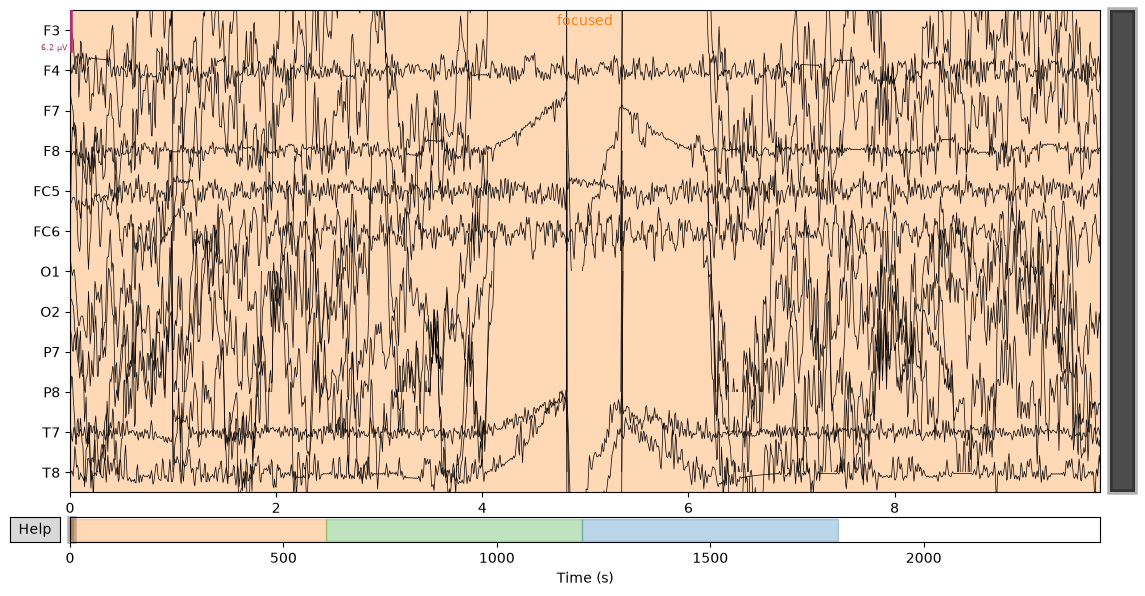

In [7]:
channel_counts = (qc.explode('auto_bads').dropna(subset=['auto_bads'])
                  .groupby('auto_bads').size().sort_values(ascending=False))
display(channel_counts.rename('recordings_flagged'))

sample_path = next(path for path in paths if path.subject == SAMPLE_SUBJECT and path.session == SAMPLE_SESSION)
sample_raw, _, sample_amplitude_bads, sample_lof_bads, _ = load_qc_raw(sample_path)
sample_auto_bads = sorted(set(sample_amplitude_bads) | set(sample_lof_bads))
print(f'{sample_path.basename}: amplitude={sample_amplitude_bads}, LOF={sample_lof_bads}, union={sample_auto_bads}')
fig = sample_raw.plot(duration=10, n_channels=len(CHANNELS), scalings='auto', show=False,
                      title='Standardized raw with BAD annotations')
fig.set_size_inches(12, 6)

if sample_auto_bads:
    interpolated = sample_raw.copy()
    interpolated.info['bads'] = sample_auto_bads
    interpolated.interpolate_bads(reset_bads=False, verbose='ERROR')
    delta_uv = (interpolated.get_data() - sample_raw.get_data()) * 1e6
    print(f'interpolation changes only {sample_auto_bads}; max |delta|={np.abs(delta_uv).max():.1f} uV')
    fig = interpolated.plot(duration=10, n_channels=len(CHANNELS), scalings='auto', show=False,
                            title='In-memory interpolation of detected bad channel(s)')
    fig.set_size_inches(12, 6)
else:
    print('This QC sample has no detected bad channel, so no interpolation is performed.')
